# Zulassungskarten

analysis of the results from pipeline.py

In [71]:
# imports
import json
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

# Load & prepare Data

## Load

In [72]:
DATA_DIR = Path("../../data/03_processed") 

records = []

for file_path in DATA_DIR.glob("*.json"):
    with file_path.open(encoding="utf-8") as file:
        record = json.load(file)

    record["_file_name"] = file_path.name
    records.append(record)

df_processed = pd.json_normalize(records, sep="_")
df = df_processed.copy()

# df

## Helper Functions

In [73]:
def parse_meters(value):
    if pd.isna(value):
        return float("nan")

    text = str(value).lower().replace("m", "").strip()
    if not text:
        return float("nan")

    # German decimal comma and thousands separators
    if "," in text:
        text = text.replace(".", "").replace(",", ".")
    else:
        text = text.replace(".", "")

    return pd.to_numeric(text, errors="coerce")

In [74]:
MONTH_NUMBERS = {
    "januar": 1,
    "februar": 2,
    "märz": 3,
    "april": 4,
    "mai": 5,
    "juni": 6,
    "juli": 7,
    "august": 8,
    "september": 9,
    "oktober": 10,
    "november": 11,
    "dezember": 12,
}


def parse_german_date(value):
    if pd.isna(value):
        return pd.NaT

    parts = str(value).strip().rstrip(".").split()
    if len(parts) != 3:
        return pd.NaT

    day = parts[0].rstrip(".")
    month = MONTH_NUMBERS.get(parts[1].lower())
    year = parts[2]

    if month is None:
        return pd.NaT

    return pd.to_datetime(
        f"{year}-{month:02d}-{day}",
        errors="coerce",
    )

## Prepare data
join metadata with processed

sort by date or examinationnumber?

In [75]:
METADATA_DIR = Path("../../data/01_raw")

if "df_processed" not in globals():
    df_processed = pd.json_normalize(records, sep="_")

metadata_records = []

for file_path in METADATA_DIR.rglob("*.json"):
    with file_path.open(encoding="utf-8") as file:
        metadata_record = json.load(file)

    # Match the metadata file to its corresponding processed file.
    metadata_record["_file_name"] = file_path.name.replace(".json", "_processed.json")
    metadata_records.append(metadata_record)

df_metadata = pd.json_normalize(metadata_records, sep="_")
df_metadata = df_metadata.rename(
    columns={
        column: f"metadata_{column}"
        for column in df_metadata.columns
        if column != "_file_name"
    }
)

df = df_processed.merge(
    df_metadata,
    on="_file_name",
    how="left",
    validate="one_to_one",
    indicator="_metadata_join",
)
df["metadata_available"] = df.pop("_metadata_join").eq("both")

# df

In [76]:
df["examination_number_parsed"] = pd.to_numeric(df["examination_number"], errors="coerce").astype("Int64")
df["metadata_Prüfnummer_parsed"] = pd.to_numeric(df["metadata_Prüfnummer"], errors="coerce").astype("Int64")

df["metadata_Länge_parsed"] = df["metadata_Länge (in Meter)"].apply(parse_meters)
# df["length_details_individual_acts"] ???
df["total_original_length_parsed"] = df["length_details_total_length_original_length"].apply(parse_meters)
df["total_length_after_cut_parsed"] = df["length_details_total_length_length_after_cut"].apply(parse_meters)

df["examination_certificate_date_parsed"] = df["examination_certificate_date"].apply(parse_german_date) # nicht jedes wird geparsed aufgrund von schlechter ocr erkennung hmmm
df["metadata_Prüfdatum_parsed"] = pd.to_datetime(df["metadata_Prüfdatum"], dayfirst=True, errors="coerce") # hier auch extra pasred spalte?
df["metadata_year"] = df["metadata_Prüfdatum_parsed"].dt.year.astype("Int64")

In [77]:
with pd.option_context("display.max_columns", None):
    display(df)

,examination_number,stamp_text,origin_company,movie_title,movie_subtitle,produced_by,director,cinematography,set_design,cast_list,excerpt_note,intertitles,_file_name,length_details_individual_acts,length_details_total_length_original_length,length_details_total_length_length_after_cut,examination_certificate_examination_board,examination_certificate_location,examination_certificate_date,examination_certificate_decision_text,metadata_Titel_und_Signatur,metadata_Prüfnummer,metadata_Prüfdatum,metadata_Antragsteller,metadata_Produktion,metadata_Land,metadata_Filmart,metadata_Stumm-/Tonfilm,metadata_Länge (in Meter),metadata_Entscheidung,metadata_Unterlagenart,metadata_Benutzungsort,metadata_Bemerkung,metadata_Vorführungsbeschränkung,metadata_Ort des Prüfdatums,metadata_available,examination_number_parsed,metadata_Prüfnummer_parsed,metadata_Länge_parsed,total_original_length_parsed,total_length_after_cut_parsed,examination_certificate_date_parsed,metadata_Prüfdatum_parsed,metadata_year
0,11751,Zulassungskarten für Bildstreifen sind öffentl...,"Universal Pictures Corp., New York",Liebestoll.,NaN,Deutsch-Nordische Film-Union G. m. b. H.,NaN,NaN,NaN,[],NaN,"[{'act_label': '1. Akt', 'text': '1. Akt. 1. E...",R 9346-I_7746_processed.json,"[{'act_number': 'I', 'original_length': '260 m...",498 m,NaN,Film-Prüfstelle Berlin,Berlin,13. November 1935,Der Bildstreifen wird zur öffentlichen Vorführ...,R 9346-I/7746\nLiebestoll.\n1920 - 1945,11751,13.11.1925,"Deutsch-Nordische Film-Union GmbH, Berlin","Universal-Pictures Corp., New York",USA,Spielfilm,Stummfilm,498,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,NaN,NaN,NaN,True,11751,11751,498.0,498.0,NaN,1935-11-13,1925-11-13,1925
1,38954,Zulassungskarten für Filme sind öffentliche Ur...,"Gebrüder Diehl-Film, Gräfeling bei München",Die Macht der Liebe.,Tobis zeigt einen Puppenfilm der Gebrüder Dieh...,Killerstraße 10/1.,NaN,Hans Asen,NaN,[],NaN,"[{'act_label': 'Fortsetzung', 'text': '2. Aha,...",R 9346-I_24154_processed.json,[],580 m,NaN,Film-Prüfstelle,Berlin,29. März 1935,Der Film wird zur öffentlichen Vorführung im D...,R 9346-I/24154\nDie Macht der Liebe\n1920 - 1945,38954,29.3.1935,"Gebr. Diehl, Gräfelfing b. München","Gebr. Diehl, Gräfelfing b. München",Deutschland,Spielfilm,Tonfilm,580,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,NaN,NaN,NaN,True,38954,38954,580.0,580.0,NaN,1935-03-29,1935-03-29,1935
2,16811,Zulassungskarten für Bildstreifen sind öffentl...,"Paramount-Film, U. S. A.",Ko Ko als Wedder.,Alfred Weiß zeigt Tintenmännchen im: Ko Ko als...,Universum-Film Aktiengesellschaft Berlin SW 68...,NaN,NaN,NaN,[],NaN,[],R 9346-I_11484_processed.json,[],181 m,NaN,Film-Prüfstelle Berlin,Berlin,3. Oktober 1927,Der Bildstreifen wird zur öffentlichen Vorführ...,R 9346-I/11484\nKo Ko als Wecker.\n1920 - 1945,16811,3.10.1927,"Universum-Film AG, Berlin","Paramount, New York",USA,Zeichentrickfilm,Stummfilm,181,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,NaN,NaN,NaN,True,16811,16811,181.0,181.0,NaN,1927-10-03,1927-10-03,1927
3,57539,NaN,"Tobis Filmkunst G. m. b. H., Berlin NW 7",Die Entlassung.,Tobis zeigt Emil Jannings in: Die Entlassung.,Friedrichstraße 100,Wolfgang Liebeneiner,Fritzz Wagner,Otto Hunte,"[{'role': 'Fürst Bismarck', 'actor': 'Emil Jan...",NaN,"[{'act_label': '1. Akt', 'text': '1. Vor dem A...",R 9346-I_35012_processed.json,"[{'act_number': '1. Rolle 1. Akt', 'original_l...",2991 m,NaN,Filmprüfstelle,Berlin,28. August 1942,Der Film wird zur öffentlichen Vorführung im D...,R 9346-I/35012\nDie Entlassung\n1920 - 1945,57539,28.8.1942,"Tobis Filmkunst GmbH, Berlin","Tobis Filmkunst GmbH, Berlin",Deutschland,Spielfilm,Tonfilm,2991,Jugendfrei vom 14. Lebensjahr ab,Zulassungskarte,Berlin-Lichterfelde,NaN,NaN,NaN,True,57539,57539,2991.0,2991.0,NaN,1942-08-28,1942-08-28,1942
4,15543,Zulassungskarten für Bildstreifen sind öffent....,"Berlin W 35, Genhinter Straße 32",Die Entstehung der Pelzmode.,Pinschewer-Film. 1. Frau Eva spricht zu ihrem ...,"Werbefilm G. m. b. H., Leitung J. Pin

## Evaluation

In [78]:
def compare_ocr_with_metadata(ocr_values, metadata_values):
    ocr_values = pd.Series(ocr_values)
    metadata_values = pd.Series(metadata_values)

    if len(ocr_values) != len(metadata_values):
        raise ValueError("Die beiden Spalten müssen gleich lang sein.")

    original_index = ocr_values.index
    ocr_values = ocr_values.reset_index(drop=True)
    metadata_values = metadata_values.reset_index(drop=True)

    metadata_available = metadata_values.notna()
    both_values_present = metadata_available & ocr_values.notna()

    identical = pd.Series(pd.NA, index=ocr_values.index, dtype="boolean")
    identical.loc[metadata_available] = False
    identical.loc[both_values_present] = ocr_values.loc[both_values_present].eq(
        metadata_values.loc[both_values_present]
    )
    evaluated_count = int(metadata_available.sum())
    correct_count = int(identical.loc[metadata_available].sum())
    accuracy = correct_count / evaluated_count if evaluated_count else None
    accuracy_text = f"{accuracy:.2%}" if accuracy is not None else "n/a"
    unverified_count = int((~metadata_available).sum())
    ocr_without_metadata_count = int(
        (~metadata_available & ocr_values.notna()).sum()
    )

    print(
        f"{correct_count} von {evaluated_count} bewertbaren Zeilen korrekt "
        f"({accuracy_text})"
    )
    print(
        f"{unverified_count} Zeilen nicht bewertbar; davon "
        f"{ocr_without_metadata_count} mit OCR-Wert ohne Metadaten"
    )
    identical.index = original_index
    return identical


In [79]:
# Titel und Signatur
def parse_title(df, column_name):
    return df[column_name].str.split('\n').str[1] 

df["metadata_Titel"] = parse_title(df, "metadata_Titel_und_Signatur")
df["movie_title_parsed"] = df["movie_title"].str.replace('.', '', regex=False)

identical_titel = compare_ocr_with_metadata(
    df["movie_title"],
    df["metadata_Titel"]
) 

print("\n")

identical_titel = compare_ocr_with_metadata(
    df["movie_title_parsed"],
    df["metadata_Titel"]
)

df_look = df[df["metadata_Titel"].isna()]
# df_look


with pd.option_context("display.max_columns", None):
    display(df_look)

472 von 2823 bewertbaren Zeilen korrekt (16.72%)
1 Zeilen nicht bewertbar; davon 1 mit OCR-Wert ohne Metadaten


745 von 2823 bewertbaren Zeilen korrekt (26.39%)
1 Zeilen nicht bewertbar; davon 1 mit OCR-Wert ohne Metadaten


,examination_number,stamp_text,origin_company,movie_title,movie_subtitle,produced_by,director,cinematography,set_design,cast_list,excerpt_note,intertitles,_file_name,length_details_individual_acts,length_details_total_length_original_length,length_details_total_length_length_after_cut,examination_certificate_examination_board,examination_certificate_location,examination_certificate_date,examination_certificate_decision_text,metadata_Titel_und_Signatur,metadata_Prüfnummer,metadata_Prüfdatum,metadata_Antragsteller,metadata_Produktion,metadata_Land,metadata_Filmart,metadata_Stumm-/Tonfilm,metadata_Länge (in Meter),metadata_Entscheidung,metadata_Unterlagenart,metadata_Benutzungsort,metadata_Bemerkung,metadata_Vorführungsbeschränkung,metadata_Ort des Prüfdatums,metadata_available,examination_number_parsed,metadata_Prüfnummer_parsed,metadata_Länge_parsed,total_original_length_parsed,total_length_after_cut_parsed,examination_certificate_date_parsed,metadata_Prüfdatum_parsed,metadata_year,metadata_Titel,movie_title_parsed
1450,54802,Zulassungskarten für Filme sind öffentliche Ur...,"Gasparcolor Werbefilme G. m. b. H., Berlin W 50",Der Imbert-Generator.,"Ein Film der Gasparcolor-Film, Berlin W 50.","Paul Schwärzel,\nunter Mitarbeit von Hasso Pre...",NaN,NaN,NaN,[],NaN,[],R_9346_I_33595_processed.json,[],NaN,NaN,Film-Prüfstelle,Berlin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,54802,<NA>,NaN,NaN,NaN,NaT,NaT,<NA>,NaN,Der Imbert-Generator


In [80]:
# Prüfnummer
identical_examination_number = compare_ocr_with_metadata(
    df["examination_number"],
    df["metadata_Prüfnummer"],
)

2670 von 2799 bewertbaren Zeilen korrekt (95.39%)
25 Zeilen nicht bewertbar; davon 25 mit OCR-Wert ohne Metadaten


In [81]:
# Manuell geprüfte Fälle ohne Metadaten hier eintragen.
manual_evaluation = {
    # "R 9346-I_123_processed.json": True,
    # "R 9346-I_456_processed.json": False,
}

manual_correct = df["_file_name"].map(manual_evaluation).astype("boolean")
evaluation = identical_examination_number.fillna(manual_correct)

evaluated_count = int(evaluation.notna().sum())
correct_count = int(evaluation.eq(True).sum())
accuracy = correct_count / evaluated_count if evaluated_count else None
accuracy_text = f"{accuracy:.2%}" if accuracy is not None else "n/a"
print(
    f"Nach manueller Bewertung: {correct_count} von {evaluated_count} "
    f"Zeilen korrekt ({accuracy_text})"
)

errors = evaluation.eq(False)

columns = [
    "examination_number",
    "metadata_Prüfnummer",
    "_file_name"
]
df_errors = df.loc[errors.fillna(False)][columns]
df_errors

Nach manueller Bewertung: 2670 von 2799 Zeilen korrekt (95.39%)


,examination_number,metadata_Prüfnummer,_file_name
27,1999,4999,R 9346-I_2715_processed.json
31,1666,4666,R 9346-I_2459_processed.json
41,8378 / 122,8378,R 9346-I_5194_processed.json
87,4098,4093,R 9346-I_2031_processed.json
124,8607\n8608,8607,R 9346-I_5366_processed.json
...,...,...,...
2708,3901,3801,R 9346-I_1854_processed.json
2752,168 7462,7468,R 9346-I_4557_processed.json
2754,441 40,44140,R 9346-I_27057_processed.json
2785,601,661,R 9346-I_120_processed.json


In [82]:
# prüfdatum
identical_date = compare_ocr_with_metadata(
    df["examination_certificate_date_parsed"],
    df["metadata_Prüfdatum_parsed"]
)

2428 von 2823 bewertbaren Zeilen korrekt (86.01%)
1 Zeilen nicht bewertbar; davon 0 mit OCR-Wert ohne Metadaten


In [83]:
df_look = df[df["examination_certificate_date_parsed"].isna()]

df_look = df_look[["_file_name","examination_certificate_date_parsed", "examination_certificate_date"]]

df_look

,_file_name,examination_certificate_date_parsed,examination_certificate_date
53,R 9346-I_23157_processed.json,NaT,16 December 1933
164,R 9346-I_34446_processed.json,NaT,NaN
198,R 9346-I_22946_processed.json,NaT,NaN
300,R 9346-I_8062_processed.json,NaT,19. Januar 1926; 03. September 1935
368,R 9346-I_21023_processed.json,NaT,20. August 1932 / 27. Juni 1932
418,R 9346-I_3947_processed.json,NaT,NaN
456,R 9346-I_13978_processed.json,NaT,31. September 1928
492,R 9346-I_19316_processed.json,NaT,8. April 1931 / 8. Januar 1936
495,R 9346-I_19290_processed.json,NaT,1. April 1931; 3. Oktober 1935
513,R 9346-I_1862_processed.json,NaT,NaN


In [84]:
identical_wtf = compare_ocr_with_metadata(
    df["metadata_Antragsteller"],
    df["metadata_Produktion"]
)

2123 von 2819 bewertbaren Zeilen korrekt (75.31%)
5 Zeilen nicht bewertbar; davon 1 mit OCR-Wert ohne Metadaten


In [85]:
# antragsteller & produktion
identical_origin_company = compare_ocr_with_metadata(
    df["origin_company"],
    df["metadata_Antragsteller"]
)

print("\n")

identical_origin_company_2 = compare_ocr_with_metadata(
    df["origin_company"],
    df["metadata_Produktion"]
)

print("\n")

identical_produced_by = compare_ocr_with_metadata(
    df["produced_by"],
    df["metadata_Antragsteller"]
)

print("\n")

identical_produced_by = compare_ocr_with_metadata(
    df["produced_by"],
    df["metadata_Produktion"]
)

df_look = df[["origin_company", "metadata_Antragsteller"]]
df_look

23 von 2820 bewertbaren Zeilen korrekt (0.82%)
4 Zeilen nicht bewertbar; davon 4 mit OCR-Wert ohne Metadaten


50 von 2819 bewertbaren Zeilen korrekt (1.77%)
5 Zeilen nicht bewertbar; davon 5 mit OCR-Wert ohne Metadaten


17 von 2820 bewertbaren Zeilen korrekt (0.60%)
4 Zeilen nicht bewertbar; davon 4 mit OCR-Wert ohne Metadaten


38 von 2819 bewertbaren Zeilen korrekt (1.35%)
5 Zeilen nicht bewertbar; davon 5 mit OCR-Wert ohne Metadaten


,origin_company,metadata_Antragsteller
0,"Universal Pictures Corp., New York","Deutsch-Nordische Film-Union GmbH, Berlin"
1,"Gebrüder Diehl-Film, Gräfeling bei München","Gebr. Diehl, Gräfelfing b. München"
2,"Paramount-Film, U. S. A.","Universum-Film AG, Berlin"
3,"Tobis Filmkunst G. m. b. H., Berlin NW 7","Tobis Filmkunst GmbH, Berlin"
4,"Berlin W 35, Genhinter Straße 32","Werbefilm GmbH, Berlin"
...,...,...
2819,"Paramount Film A.-G., Berlin SW 68 Friedrichst...","Paramount-Film AG, Berlin"
2820,"C. A. Linke & Co., Dresden, Jüdenhof 2","C.A. Linke u. Co., Dresden"
2821,"Fox-Film Corporation, New York, Amerika",Deulig-Film
2822,"Briesse Schmalfilm, Dr. Gerd Briese","Briese-Schmalfilm, Dr. Gerd Briese, Berlin-Cha..."


In [86]:
# Länge (in Meter)
identical_length = compare_ocr_with_metadata(
    df["total_original_length_parsed"],
    df["metadata_Länge_parsed"]
)

2343 von 2778 bewertbaren Zeilen korrekt (84.34%)
46 Zeilen nicht bewertbar; davon 42 mit OCR-Wert ohne Metadaten


# Analysis

## Filmlength & cuts

Film ungeschnitten:
- `length after cut`fehlt 
- in den einzlenen Akten keine `length after cut` angaben vorhanden ist # lowkey unnötig?

nicht bestimmbar
- fälle mit widersprüchlichen/unollständigen cut angaben
- z.B. cut größer als eigentliche länge
- => 10 nicht bestimmbar 

---

- kürzungen/länge pro jahr?
- durchschnittliche kürzung pro jahr?
- median der kürzung pro jahr?
- anteil der filme mit kürzungen?


In [87]:
df_filmlength = df[[
    "_file_name", 
    "movie_title",
    "metadata_year",
    "metadata_Entscheidung",
    "metadata_Länge_parsed", 
    "total_original_length_parsed", 
    "total_length_after_cut_parsed", 
    "length_details_individual_acts"
]].copy()

def has_after_cut_length(acts):
    if not isinstance(acts, list):
        return False

    return any(
        isinstance(act, dict)
        and pd.notna(parse_meters(act.get("length_after_cut")))
        for act in acts
    )

df_filmlength["cut_length_in_acts_available"] = (
    df_filmlength["length_details_individual_acts"].apply(has_after_cut_length)
)
df_filmlength["cut_length_available"] = (
    df_filmlength["total_original_length_parsed"].notna()
    & df_filmlength["total_length_after_cut_parsed"].notna()
)

valid_lengths = (
    df_filmlength["cut_length_available"]
    & df_filmlength["total_original_length_parsed"].gt(0)
    & df_filmlength["total_length_after_cut_parsed"].le(df_filmlength["total_original_length_parsed"])
)

# Fehlt jede Angabe zu einem Schnitt, wird der Film als ungeschnitten
# behandelt. Unvollständige Cut-Angaben bleiben dagegen unbekannt.
df_filmlength["uncut_inferred"] = (
    df_filmlength["total_length_after_cut_parsed"].isna()
    & ~df_filmlength["cut_length_in_acts_available"]
)

df_filmlength["cut_meters"] = (
    df_filmlength["total_original_length_parsed"] - df_filmlength["total_length_after_cut_parsed"]
).where(valid_lengths)
df_filmlength.loc[df_filmlength["uncut_inferred"], "cut_meters"] = 0

df_filmlength["cut_rate"] = (
    df_filmlength["cut_meters"] / df_filmlength["total_original_length_parsed"]
).where(valid_lengths)

df_filmlength.loc[
    df_filmlength["uncut_inferred"]
    & df_filmlength["total_original_length_parsed"].gt(0),
    "cut_rate",
] = 0

df_filmlength["length_after_cut_for_analysis"] = (
    df_filmlength["total_length_after_cut_parsed"]
    .where(valid_lengths)
)
df_filmlength.loc[
    df_filmlength["uncut_inferred"],
    "length_after_cut_for_analysis",
] = df_filmlength.loc[
    df_filmlength["uncut_inferred"],
    "total_original_length_parsed",
]

df_filmlength["cut_status"] = "nicht bestimmbar"
df_filmlength.loc[
    df_filmlength["uncut_inferred"]
    | (valid_lengths & df_filmlength["cut_meters"].eq(0)),
    "cut_status",
] = "ungeschnitten"
df_filmlength.loc[
    valid_lengths & df_filmlength["cut_meters"].gt(0),
    "cut_status",
] = "geschnitten"

df_filmlength["films_with_cut"] = df_filmlength["cut_status"].eq("geschnitten")
df_filmlength["films_without_cut"] = df_filmlength["cut_status"].eq("ungeschnitten")
df_filmlength["cut_status_unknown"] = df_filmlength["cut_status"].eq("nicht bestimmbar")

df_filmlength

,_file_name,movie_title,metadata_year,metadata_Entscheidung,metadata_Länge_parsed,total_original_length_parsed,total_length_after_cut_parsed,length_details_individual_acts,cut_length_in_acts_available,cut_length_available,uncut_inferred,cut_meters,cut_rate,length_after_cut_for_analysis,cut_status,films_with_cut,films_without_cut,cut_status_unknown
0,R 9346-I_7746_processed.json,Liebestoll.,1925,Jugendverbot,498.0,498.0,NaN,"[{'act_number': 'I', 'original_length': '260 m...",False,False,True,0.0,0.0,498.0,ungeschnitten,False,True,False
1,R 9346-I_24154_processed.json,Die Macht der Liebe.,1935,Jugendfrei,580.0,580.0,NaN,[],False,False,True,0.0,0.0,580.0,ungeschnitten,False,True,False
2,R 9346-I_11484_processed.json,Ko Ko als Wedder.,1927,Jugendfrei,181.0,181.0,NaN,[],False,False,True,0.0,0.0,181.0,ungeschnitten,False,True,False
3,R 9346-I_35012_processed.json,Die Entlassung.,1942,Jugendfrei vom 14. Lebensjahr ab,2991.0,2991.0,NaN,"[{'act_number': '1. Rolle 1. Akt', 'original_l...",False,False,True,0.0,0.0,2991.0,ungeschnitten,False,True,False
4,R 9346-I_10472_processed.json,Die Entstehung der Pelzmode.,1927,Jugendfrei,94.0,94.0,NaN,[],False,False,True,0.0,0.0,94.0,ungeschnitten,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2819,R 9346-I_20179_processed.json,Mann über Bord.,1931,Jugendverbot,2200.0,2200.0,NaN,"[{'act_number': 'I', 'original_length': '292 m...",False,False,True,0.0,0.0,2200.0,ungeschnitten,False,True,False
2820,R 9346-I_5875_processed.json,Gehöhrte Räuber.,1924,Jugendfrei,393.0,393.0,NaN,[],False,False,True,0.0,0.0,393.0,ungeschnitten,False,True,False
2821,R 9346-I_4696_processed.json,Die Wölfin.,1923,Jugendfrei,539.0,539.0,NaN,"[{'act_number': 'I', 'original_length': '241 m...",False,False,True,0.0,0.0,539.0,ungeschnitten,False,True,False
2822,R 9346-I_29422_processed.json,Neue Möbel im neuen Heim. (Schmalfilm.),1938,Jugendfrei,16.0,16.0,NaN,[],False,False,True,0.0,0.0,16.0,ungeschnitten,False,True,False


In [89]:
yearly_length = (
    df_filmlength.dropna(subset=["metadata_year"])
    .groupby("metadata_year")
    .agg(
        records=("_file_name", "count"),
        records_with_original_length=("total_original_length_parsed", "count"),
        records_with_after_cut_length=("cut_length_available", "sum"),
        records_with_cut_status=("cut_status", lambda values: values.ne("nicht bestimmbar").sum()),
        films_with_cut=("films_with_cut", "sum"),
        films_without_cut=("films_without_cut", "sum"),
        records_cut_status_unknown=("cut_status_unknown", "sum"),
        records_length=("total_original_length_parsed", "sum"),
        records_cut_meters=("cut_meters", "sum"),

        metadata_Länge_mean=("metadata_Länge_parsed", "mean"),
        metadata_Länge_median=("metadata_Länge_parsed", "median"),

        total_original_length_mean=("total_original_length_parsed", "mean"),
        total_original_length_median=("total_original_length_parsed", "median"),

        total_length_after_cut_mean=("length_after_cut_for_analysis", "mean"),
        total_length_after_cut_median=("length_after_cut_for_analysis", "median"),

        cut_meters_mean=("cut_meters", "mean"),
        cut_meters_median=("cut_meters", "median"),
        cut_rate_mean=("cut_rate", "mean"),
        cut_rate_median=("cut_rate", "median")
    )
)

yearly_length["cut_share_percent"] = (
    yearly_length["films_with_cut"]
    .div(yearly_length["records"])
    .mul(100)
    .where(yearly_length["records"].gt(0))
)
yearly_length["uncut_share_percent"] = (
    yearly_length["films_without_cut"]
    .div(yearly_length["records"])
    .mul(100)
    .where(yearly_length["records"].gt(0))
)

yearly_length.round(2)

,records,records_with_original_length,records_with_after_cut_length,records_with_cut_status,films_with_cut,films_without_cut,records_cut_status_unknown,records_length,records_cut_meters,metadata_Länge_mean,...,total_original_length_mean,total_original_length_median,total_length_after_cut_mean,total_length_after_cut_median,cut_meters_mean,cut_meters_median,cut_rate_mean,cut_rate_median,cut_share_percent,uncut_share_percent
metadata_year,,,,,,,,,,,,,,,,,,,,,
1917,3,3,0,3,0,3,0,832.0,0.00,277.33,...,277.33,371.0,277.33,371.0,0.00,0.0,0.00,0.0,0.00,100.00
1920,71,71,10,71,10,61,0,89135.0,192.50,1258.80,...,1255.42,1315.0,1252.71,1315.0,2.71,0.0,0.00,0.0,14.08,85.92
1921,120,116,17,117,14,103,3,119430.0,219.35,1035.22,...,1029.57,998.5,993.94,920.0,1.87,0.0,0.00,0.0,11.67,85.83
1922,120,116,3,120,3,117,0,89315.0,44.25,767.97,...,769.96,385.0,769.58,385.0,0.37,0.0,0.00,0.0,2.50,97.50
1923,120,118,8,120,8,112,0,110073.0,79.25,931.75,...,932.82,552.5,932.15,552.5,0.66,0.0,0.00,0.0,6.67,93.33
1924,120,118,5,119,5,114,1,113945.0,103.50,964.28,...,965.64,636.0,970.13,639.0,0.87,0.0,0.00,0.0,4.17,95.00
1925,120,118,0,120,0,120,0,90144.0,0.00,757.47,...,763.93,477.5,763.93,477.5,0.00,0.0,0.00,0.0,0.00,100.00
1926,120,117,6,119,5,114,1,85655.0,107.70,708.90,...,732.09,308.0,719.72,302.0,0.91,0.0,0.00,0.0,4.17,95.00
1927,120,119,4,120,4,116,0,79012.0,14.73,661.33,...,663.97,250.0,663.84,250.0,0.12,0.0,0.00,0.0,3.33,96.67


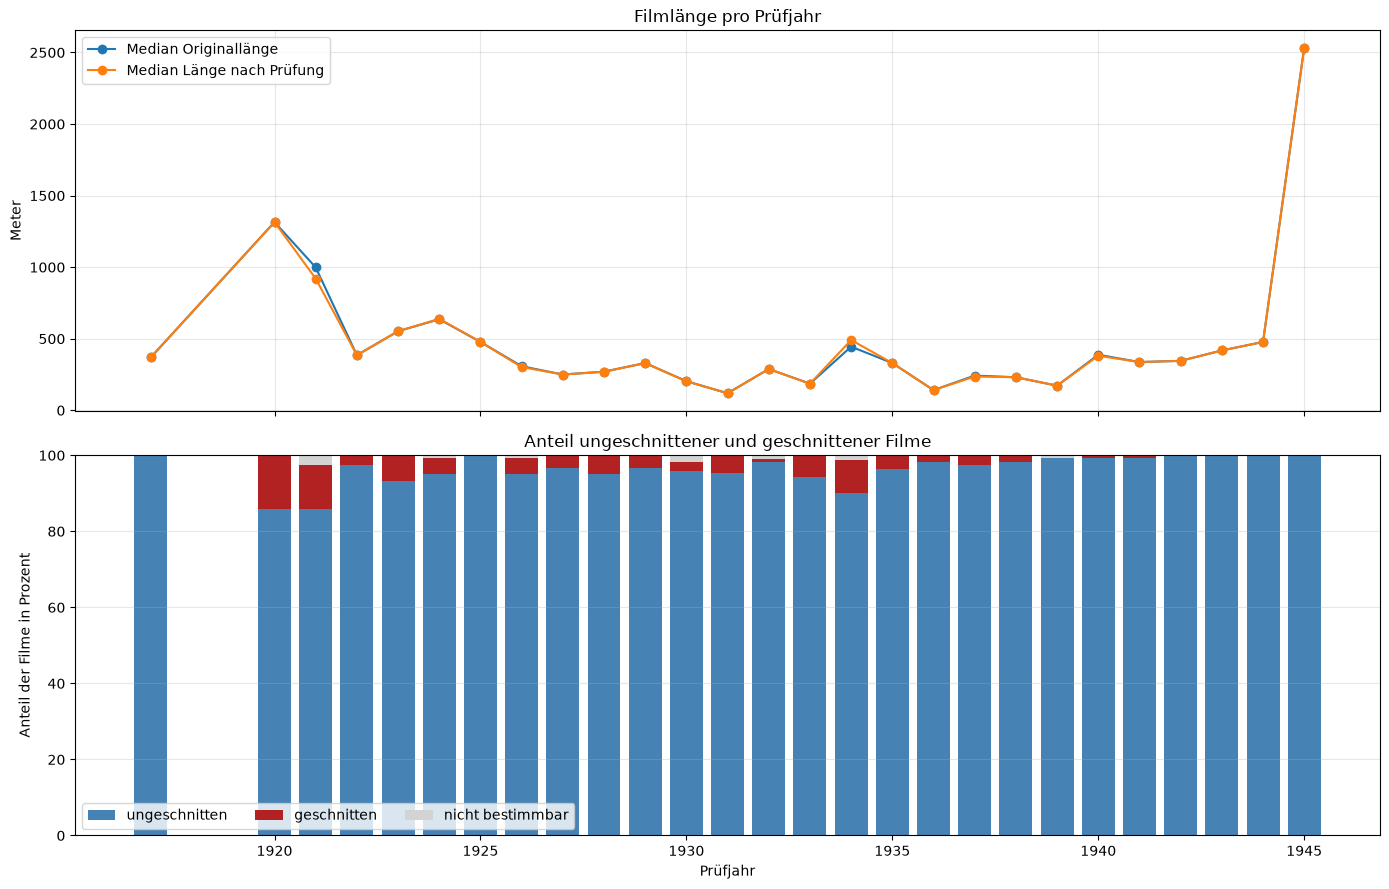

In [90]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(
    yearly_length.index,
    yearly_length["total_original_length_median"],
    marker="o",
    label="Median Originallänge",
)
axes[0].plot(
    yearly_length.index,
    yearly_length["total_length_after_cut_median"],
    marker="o",
    label="Median Länge nach Prüfung",
)
axes[0].set_title("Filmlänge pro Prüfjahr")
axes[0].set_ylabel("Meter")
axes[0].grid(alpha=0.3)
axes[0].legend()

plot_data = yearly_length
axes[1].bar(
    plot_data.index,
    plot_data["uncut_share_percent"],
    label="ungeschnitten",
    color="steelblue",
)
axes[1].bar(
    plot_data.index,
    plot_data["cut_share_percent"],
    bottom=plot_data["uncut_share_percent"],
    label="geschnitten",
    color="firebrick",
)
axes[1].bar(
    plot_data.index,
    plot_data["records_cut_status_unknown"]
    .div(plot_data["records"])
    .mul(100),
    bottom=plot_data["uncut_share_percent"] + plot_data["cut_share_percent"],
    label="nicht bestimmbar",
    color="lightgray",
)
axes[1].set_title("Anteil ungeschnittener und geschnittener Filme")
axes[1].set_xlabel("Prüfjahr")
axes[1].set_ylabel("Anteil der Filme in Prozent")
axes[1].set_ylim(0, 100)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(ncol=3)

plt.tight_layout()
plt.show()

### Individual Acts
- durchschnittliche Akt anzahl?
    - min/max auch zeigen?
- durchschnittliche länge pro Akt?

In [91]:
df_filmlength_acts = (
    df_filmlength
    .explode("length_details_individual_acts", ignore_index=True)
    .dropna(subset=["length_details_individual_acts"])
    .reset_index(drop=True)
)

df_filmlength_acts = pd.concat(
    [
        df_filmlength_acts.drop(columns="length_details_individual_acts"),
        pd.json_normalize(df_filmlength_acts["length_details_individual_acts"]),
    ],
    axis=1,
)

df_filmlength_acts["original_length"] = df_filmlength_acts["original_length"].apply(parse_meters)
df_filmlength_acts["length_after_cut"] = df_filmlength_acts["length_after_cut"].apply(parse_meters)

df_filmlength_acts["act_length_after_cut_for_analysis"] = (
    df_filmlength_acts["length_after_cut"]
)
known_cut_status = df_filmlength_acts["cut_status"].isin(
    ["geschnitten", "ungeschnitten"]
)
unchanged_acts = known_cut_status & df_filmlength_acts["length_after_cut"].isna()
df_filmlength_acts.loc[unchanged_acts, "act_length_after_cut_for_analysis"] = (
    df_filmlength_acts.loc[unchanged_acts, "original_length"]
)

df_filmlength_acts

,_file_name,movie_title,metadata_year,metadata_Entscheidung,metadata_Länge_parsed,total_original_length_parsed,total_length_after_cut_parsed,cut_length_in_acts_available,cut_length_available,uncut_inferred,...,cut_rate,length_after_cut_for_analysis,cut_status,films_with_cut,films_without_cut,cut_status_unknown,act_number,original_length,length_after_cut,act_length_after_cut_for_analysis
0,R 9346-I_7746_processed.json,Liebestoll.,1925,Jugendverbot,498.0,498.0,NaN,False,False,True,...,0.0,498.0,ungeschnitten,False,True,False,I,260.0,NaN,260.0
1,R 9346-I_7746_processed.json,Liebestoll.,1925,Jugendverbot,498.0,498.0,NaN,False,False,True,...,0.0,498.0,ungeschnitten,False,True,False,II,238.0,NaN,238.0
2,R 9346-I_35012_processed.json,Die Entlassung.,1942,Jugendfrei vom 14. Lebensjahr ab,2991.0,2991.0,NaN,False,False,True,...,0.0,2991.0,ungeschnitten,False,True,False,1. Rolle 1. Akt,334.0,NaN,334.0
3,R 9346-I_35012_processed.json,Die Entlassung.,1942,Jugendfrei vom 14. Lebensjahr ab,2991.0,2991.0,NaN,False,False,True,...,0.0,2991.0,ungeschnitten,False,True,False,2. Rolle 2. u. 3. Akt,536.0,NaN,536.0
4,R 9346-I_35012_processed.json,Die Entlassung.,1942,Jugendfrei vom 14. Lebensjahr ab,2991.0,2991.0,NaN,False,False,True,...,0.0,2991.0,ungeschnitten,False,True,False,3. Rolle 4. u. 5. Akt,559.0,NaN,559.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5252,R 9346-I_20179_processed.json,Mann über Bord.,1931,Jugendverbot,2200.0,2200.0,NaN,False,False,True,...,0.0,2200.0,ungeschnitten,False,True,False,VIII,270.0,NaN,270.0
5253,R 9346-I_4696_processed.json,Die Wölfin.,1923,Jugendfrei,539.0,539.0,NaN,False,False,True,...,0.0,539.0,ungeschnitten,False,True,False,I,241.0,NaN,241.0
5254,R 9346-I_4696_processed.json,Die Wölfin.,1923,Jugendfrei,539.0,539.0,NaN,False,False,True,...,0.0,539.0,ungeschnitten,False,True,False,II,298.0,NaN,298.0
5255,R 9346-I_3928_processed.json,Eine Nacht gelebt im,1922,Jugendverbot,564.0,564.0,NaN,False,False,True,...,0.0,564.0,ungeschnitten,False,True,False,I,330.0,NaN,330.0


In [92]:
df_filmlength["act_count"] = df_filmlength["length_details_individual_acts"].map(len)

yearly_individual_acts = (
    df_filmlength.dropna(subset=["metadata_year"])
    .groupby("metadata_year")
    .agg(
        records=("_file_name", "count"),
        films_with_individual_acts=("act_count", lambda values: values.gt(0).sum()),
        total_acts=("act_count", "sum"),
        mean_act_count=("act_count", "mean"),
        median_act_count=("act_count", "median"),
    )
)

yearly_act_lengths = (
    df_filmlength_acts.dropna(subset=["metadata_year"])
    .groupby("metadata_year")
    .agg(
        acts_with_original_length=("original_length", "count"),
        mean_act_length=("original_length", "mean"),
        median_act_length=("original_length", "median"),
        acts_with_after_cut_length=("act_length_after_cut_for_analysis", "count"),
        mean_act_length_after_cut=("act_length_after_cut_for_analysis", "mean"),
        median_act_length_after_cut=("act_length_after_cut_for_analysis", "median"),
    )
)

yearly_individual_acts = yearly_individual_acts.join(yearly_act_lengths)
yearly_individual_acts["acts_with_original_length"] = (
    yearly_individual_acts["acts_with_original_length"]
    .fillna(0)
    .astype("Int64")
)
yearly_individual_acts["acts_with_after_cut_length"] = (
    yearly_individual_acts["acts_with_after_cut_length"]
    .fillna(0)
    .astype("Int64")
)
yearly_individual_acts.round(2)

,records,films_with_individual_acts,total_acts,mean_act_count,median_act_count,acts_with_original_length,mean_act_length,median_act_length,acts_with_after_cut_length,mean_act_length_after_cut,median_act_length_after_cut
metadata_year,,,,,,,,,,,
1917,3,0,0,0.00,0.0,0,NaN,NaN,0,NaN,NaN
1920,71,53,255,3.59,5.0,254,341.11,345.0,254,341.09,345.0
1921,120,80,354,2.95,3.0,354,327.50,315.0,338,325.96,312.0
1922,120,56,250,2.08,0.0,250,315.84,312.0,250,315.79,312.0
1923,120,73,321,2.68,2.0,320,315.64,302.0,320,315.87,302.5
1924,120,74,332,2.77,2.0,332,322.34,306.5,331,322.25,306.0
1925,120,60,235,1.96,1.0,235,325.24,310.0,235,325.24,310.0
1926,120,46,216,1.80,0.0,215,323.68,312.0,211,319.06,308.0
1927,120,45,214,1.78,0.0,214,315.41,304.0,214,315.23,304.0


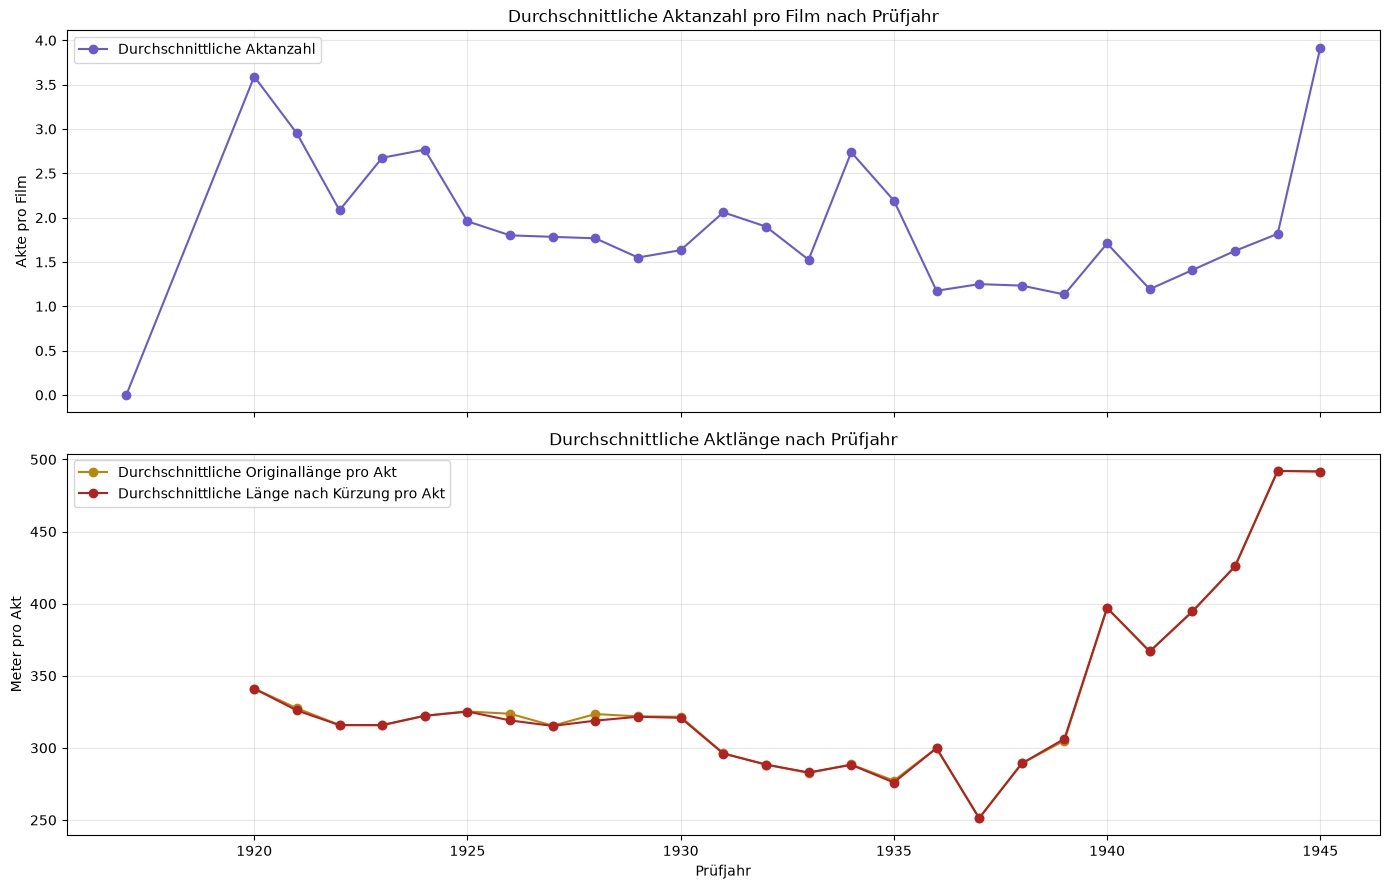

In [93]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(
    yearly_individual_acts.index,
    yearly_individual_acts["mean_act_count"],
    marker="o",
    color="slateblue",
    label="Durchschnittliche Aktanzahl",
)
axes[0].set_title("Durchschnittliche Aktanzahl pro Film nach Prüfjahr")
axes[0].set_ylabel("Akte pro Film")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    yearly_individual_acts.index,
    yearly_individual_acts["mean_act_length"],
    marker="o",
    color="darkgoldenrod",
    label="Durchschnittliche Originallänge pro Akt",
)
axes[1].plot(
    yearly_individual_acts.index,
    yearly_individual_acts["mean_act_length_after_cut"],
    marker="o",
    color="firebrick",
    label="Durchschnittliche Länge nach Kürzung pro Akt",
)
axes[1].set_title("Durchschnittliche Aktlänge nach Prüfjahr")
axes[1].set_xlabel("Prüfjahr")
axes[1].set_ylabel("Meter pro Akt")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Cuts & Decision

In [88]:
decision_cut_summary = (
    df_filmlength.assign(
        decision=df_filmlength["metadata_Entscheidung"].fillna("(fehlend)")
    )
    .groupby("decision")
    .agg(
        records=("_file_name", "count"),
        records_with_cut_status=("cut_status", lambda values: values.ne("nicht bestimmbar").sum()),
        films_with_cut=("films_with_cut", "sum"),
        films_without_cut=("films_without_cut", "sum"),
        records_cut_status_unknown=("cut_status_unknown", "sum"),
    )
    .sort_values("films_with_cut", ascending=False)
)

decision_cut_summary["cut_share_percent"] = (
    decision_cut_summary["films_with_cut"]
    .div(decision_cut_summary["records"])
    .mul(100)
)

decision_cut_summary.round(2)

,records,records_with_cut_status,films_with_cut,films_without_cut,records_cut_status_unknown,cut_share_percent
decision,,,,,,
Jugendverbot,676,669,63,606,7,9.32
Jugendfrei,2094,2092,30,2062,2,1.43
(fehlend),8,7,0,7,1,0.00
Jugendfrei vom 14. Lebensjahr ab,44,44,0,44,0,0.00
nur für bestimmte Personengruppen,2,2,0,2,0,0.00


## Intertitles

In [94]:
df_intertitles = pd.json_normalize(
    records,
    record_path="intertitles",
    meta=[
        "examination_number",
        "movie_title",
        "_file_name"
    ],
    errors="ignore",
    sep="_"
)

df_intertitles

,act_label,text,examination_number,movie_title,_file_name
0,1. Akt,"1. Akt. 1. Ein junger Aduläter, der um sein Le...",11751,Liebestoll.,R 9346-I_7746_processed.json
1,Fortsetzung,"herein! 10. Komm, komm! Du kriegst den Fuß von...",11751,Liebestoll.,R 9346-I_7746_processed.json
2,2. Akt,1. Das war also Dein verlorener Käfer! 2. Bon ...,11751,Liebestoll.,R 9346-I_7746_processed.json
3,Fortsetzung,"2. Aha, sozusagen Landgüter! 3. Wie groß sein ...",38954,Die Macht der Liebe.,R 9346-I_24154_processed.json
4,Fortsetzung,"Brief. 20. Du willst schon gehen, Emil? 21. Ic...",38954,Die Macht der Liebe.,R 9346-I_24154_processed.json
...,...,...,...,...,...
10630,Fortsetzung,kommt Du ins Zuchthaus! 6. Weil ich Ihnen eine...,30403,Mann über Bord.,R 9346-I_20179_processed.json
10631,Fortsetzung,möchte ich Dir ins Spital verhelfen. 35. Wird ...,30403,Mann über Bord.,R 9346-I_20179_processed.json
10632,1. Akt,"1. William Fox gehört sich darzubieten; 2. ""Di...",7647,Die Wölfin.,R 9346-I_4696_processed.json
10633,2. Akt,1. Ende.,7647,Die Wölfin.,R 9346-I_4696_processed.json
